# Einflussanalyse Kundenzufriedenheit

In [24]:
import sys
import os

sys.path.append(
    os.path.abspath(
        os.path.join(os.getcwd(), "..")
    )
)

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency,
    pearsonr,
    spearmanr
)

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Plot Settings
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

1. LOAD DATA UND DATA OVERVIEW

In [25]:
from db.data_loader import load_data

df = load_data()

df.head()

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()
df.shape

Rows: 1200
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datum                1200 non-null   str    
 1   marke                1200 non-null   str    
 2   modell               1200 non-null   str    
 3   preis_euro           1200 non-null   int64  
 4   verkaufszahl         1200 non-null   int64  
 5   kraftstoff           1200 non-null   str    
 6   getriebe             1200 non-null   str    
 7   hubraum_l            1200 non-null   float64
 8   bundesland           1200 non-null   str    
 9   kundenzufriedenheit  1200 non-null   float64
 10  jahr                 1200 non-null   int64  
 11  monat                1200 non-null   int64  
 12  wochentag            1200 non-null   str    
dtypes: float64(2), int64(4), str(7)
memory usage: 122.0 KB


(1200, 13)

1.1 Numerische und Kategorische Variablen 

In [26]:
numerical_columns = [
    "preis_euro",
    "verkaufszahl",
    "hubraum_l",
    "kundenzufriedenheit",
    "jahr",
    "monat"
]

categorical_columns = [
    "marke",
    "modell",
    "kraftstoff",
    "getriebe",
    "bundesland",
    "wochentag"
]

print(numerical_columns)
print(categorical_columns)

['preis_euro', 'verkaufszahl', 'hubraum_l', 'kundenzufriedenheit', 'jahr', 'monat']
['marke', 'modell', 'kraftstoff', 'getriebe', 'bundesland', 'wochentag']


In [27]:
# Zielvariable erstellen
df["zufrieden"] = (
    df["kundenzufriedenheit"] >= 3.5
).astype(int)

df["zufrieden"].value_counts()

zufrieden
1    937
0    263
Name: count, dtype: int64

2. Einflussanalyse der Kundenzufriedenheit

2.1 Numerische Einflussvariablen

Mittelwert nach Kundenzufriedenheit

In [41]:
mittelwerte = (
    df.groupby("zufrieden")[numerical_columns]
    .mean()
    .round(2)
)

display(mittelwerte)

,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
zufrieden,,,,,,
0,59935.48,5.32,1.49,3.22,2024.48,6.27
1,60598.86,4.96,1.44,4.25,2024.56,6.67


Boxplots

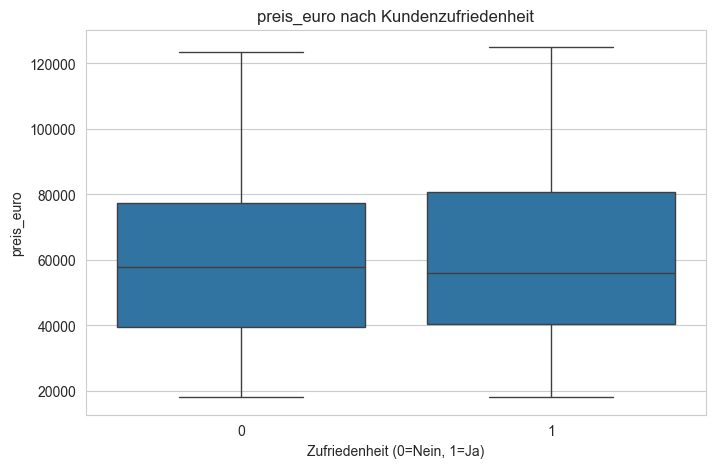

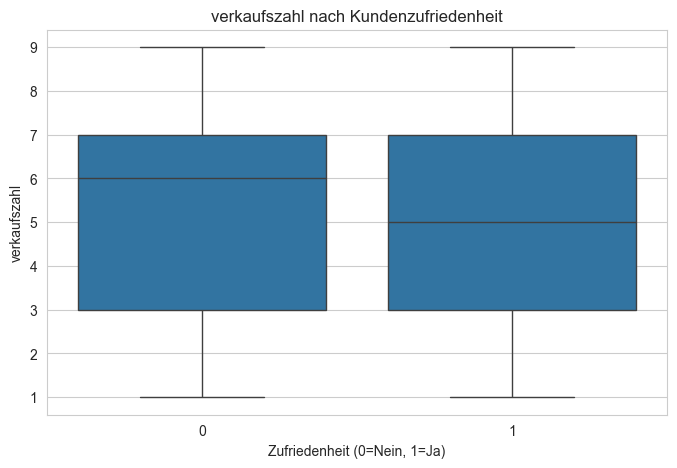

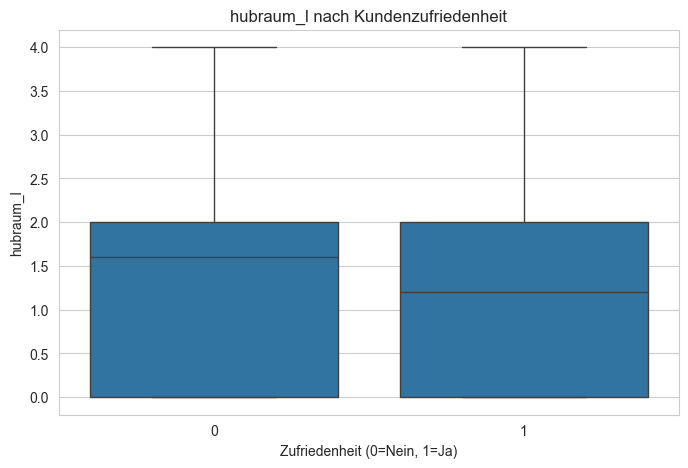

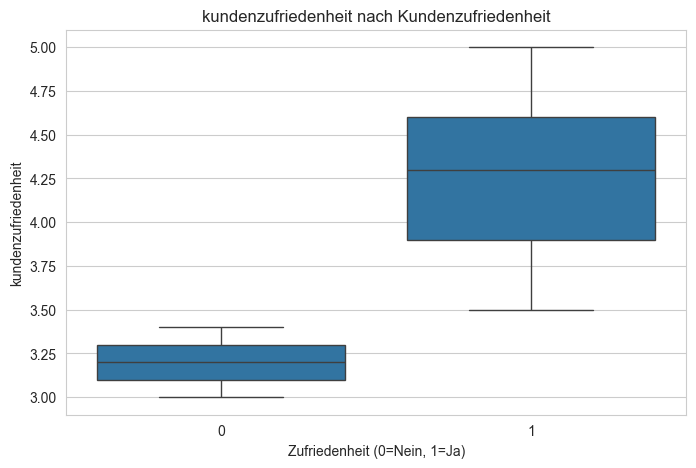

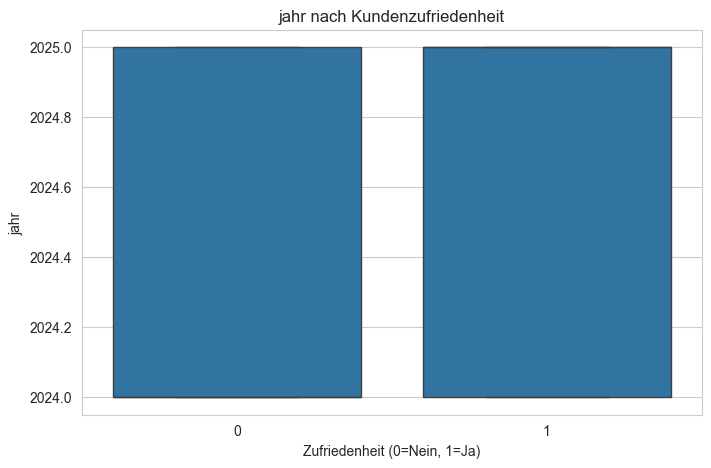

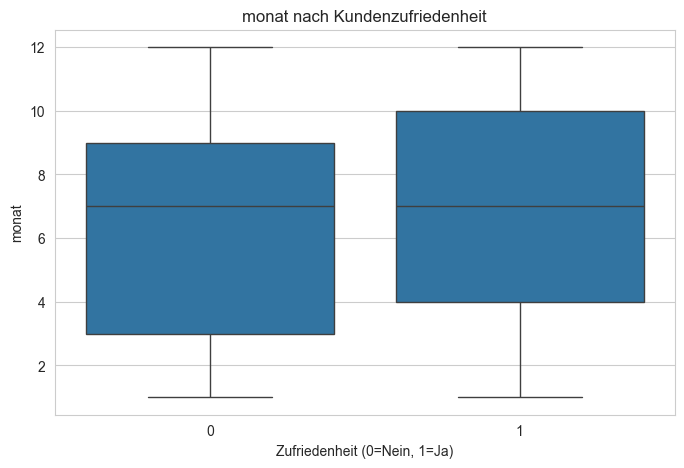

In [42]:
for feature in numerical_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="zufrieden",
        y=feature
    )

    plt.title(
        f"{feature} nach Kundenzufriedenheit"
    )
    plt.xlabel("Zufriedenheit (0=Nein, 1=Ja)")
    plt.ylabel(feature)

    plt.show()

t-Tests

In [43]:
from scipy.stats import ttest_ind

for feature in numerical_columns:

    gruppe_1 = df[
        df["zufrieden"] == 1
    ][feature]

    gruppe_0 = df[
        df["zufrieden"] == 0
    ][feature]

    t_stat, p_value = ttest_ind(
        gruppe_1,
        gruppe_0,
        equal_var=False
    )

    print("=" * 60)
    print(f"Variable: {feature}")
    print(f"t-Wert: {t_stat:.3f}")
    print(f"p-Wert: {p_value:.5f}")

    if p_value < 0.05:
        print("H0 wird verworfen.")
        print(
            f"{feature} beeinflusst die Kundenzufriedenheit signifikant."
        )
    else:
        print("H0 kann nicht verworfen werden.")
        print(
            f"Für {feature} konnte kein signifikanter Einfluss nachgewiesen werden."
        )

Variable: preis_euro
t-Wert: 0.373
p-Wert: 0.70918
H0 kann nicht verworfen werden.
Für preis_euro konnte kein signifikanter Einfluss nachgewiesen werden.
Variable: verkaufszahl
t-Wert: -2.046
p-Wert: 0.04136
H0 wird verworfen.
verkaufszahl beeinflusst die Kundenzufriedenheit signifikant.
Variable: hubraum_l
t-Wert: -0.489
p-Wert: 0.62514
H0 kann nicht verworfen werden.
Für hubraum_l konnte kein signifikanter Einfluss nachgewiesen werden.
Variable: kundenzufriedenheit
t-Wert: 61.682
p-Wert: 0.00000
H0 wird verworfen.
kundenzufriedenheit beeinflusst die Kundenzufriedenheit signifikant.
Variable: jahr
t-Wert: 2.189
p-Wert: 0.02916
H0 wird verworfen.
jahr beeinflusst die Kundenzufriedenheit signifikant.
Variable: monat
t-Wert: 1.700
p-Wert: 0.08984
H0 kann nicht verworfen werden.
Für monat konnte kein signifikanter Einfluss nachgewiesen werden.


2.2 Kategoriale Einflussvariablen

Crosstabs

In [44]:
for feature in categorical_columns:

    print("=" * 70)
    print(f"Crosstab für: {feature}")

    table = pd.crosstab(
        df[feature],
        df["zufrieden"],
        normalize="index"
    ).round(3)

    display(table)

Crosstab für: marke


zufrieden,0,1
marke,,
Audi,0.212,0.788
Bmw,0.227,0.773
Mercedes-Benz,0.211,0.789
Opel,0.220,0.780
Volkswagen,0.224,0.776


Crosstab für: modell


zufrieden,0,1
modell,,
3Er,0.263,0.737
5Er,0.239,0.761
A4,0.190,0.810
A6,0.234,0.766
Astra,0.140,0.860
C-Klasse,0.262,0.738
Corsa,0.224,0.776
E-Klasse,0.213,0.787
E-Tron,0.254,0.746


Crosstab für: kraftstoff


...

zufrieden,0,1
getriebe,,
Automatik,0.228,0.772
Manuell,0.211,0.789


Crosstab für: bundesland


zufrieden,0,1
bundesland,,
Baden-Württemberg,0.219,0.781
Bayern,0.209,0.791
Berlin,0.253,0.747
Hamburg,0.244,0.756
Hessen,0.183,0.817
Nrw,0.211,0.789


Crosstab für: wochentag


zufrieden,0,1
wochentag,,
Friday,0.174,0.826
Monday,0.204,0.796
Saturday,0.250,0.750
Sunday,0.236,0.764
Thursday,0.225,0.775
Tuesday,0.214,0.786
Wednesday,0.226,0.774


Stacked Bar Charts

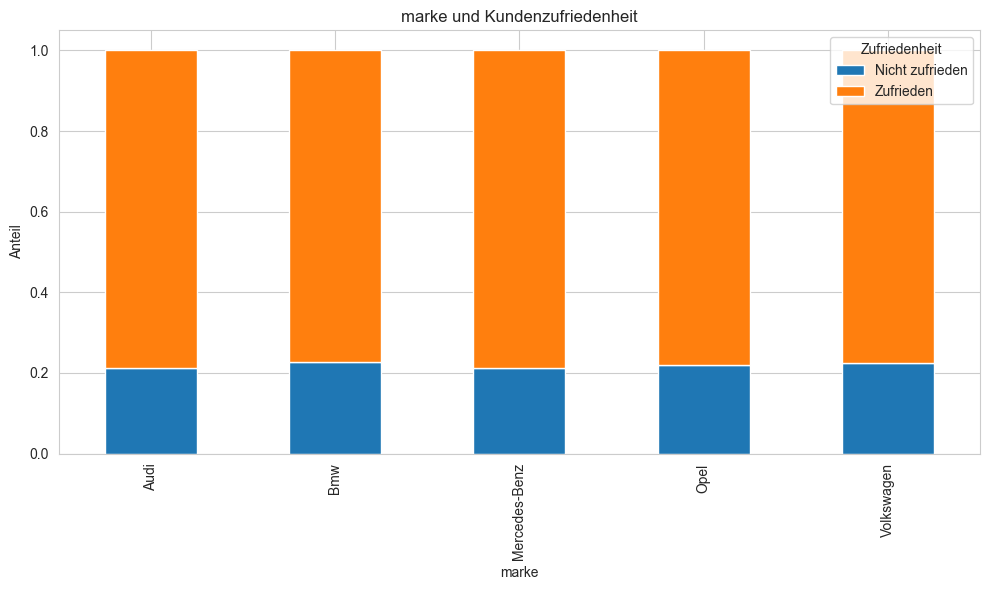

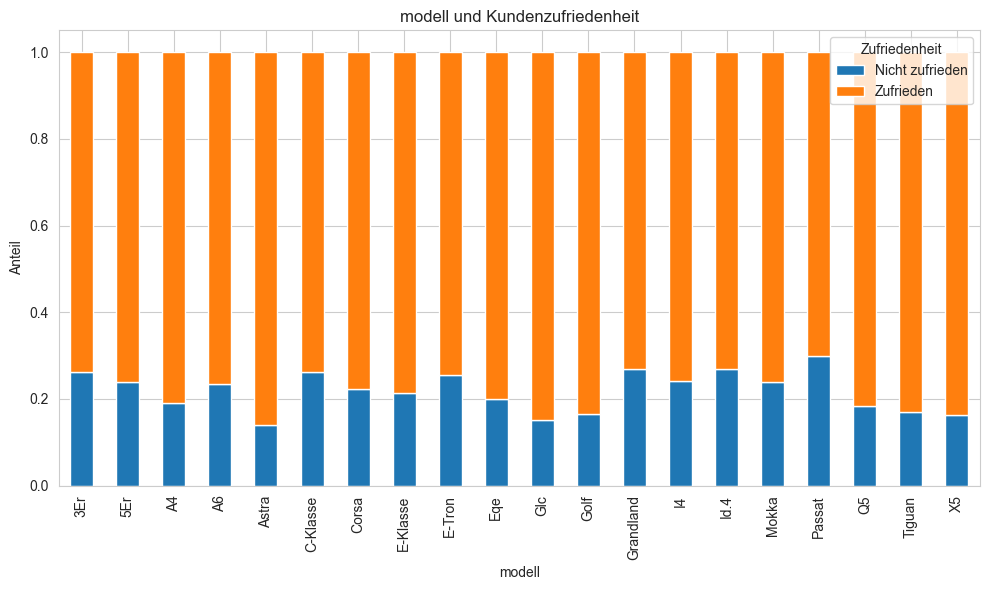

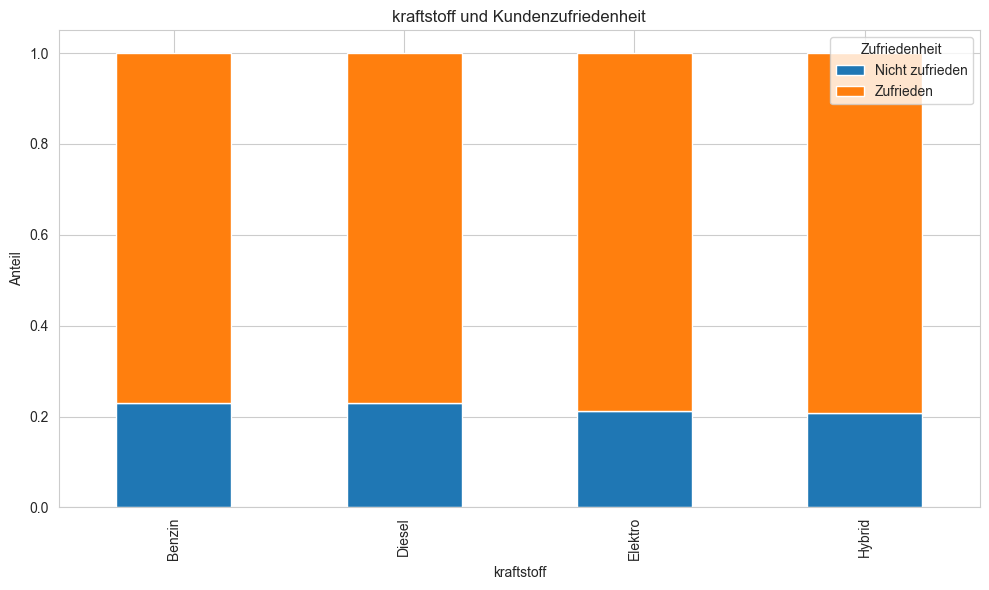

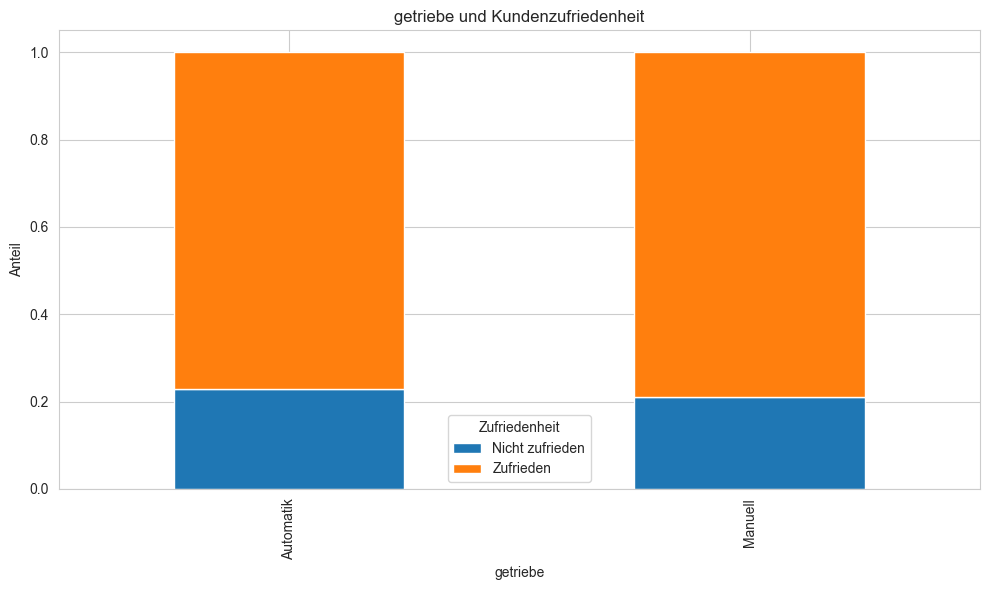

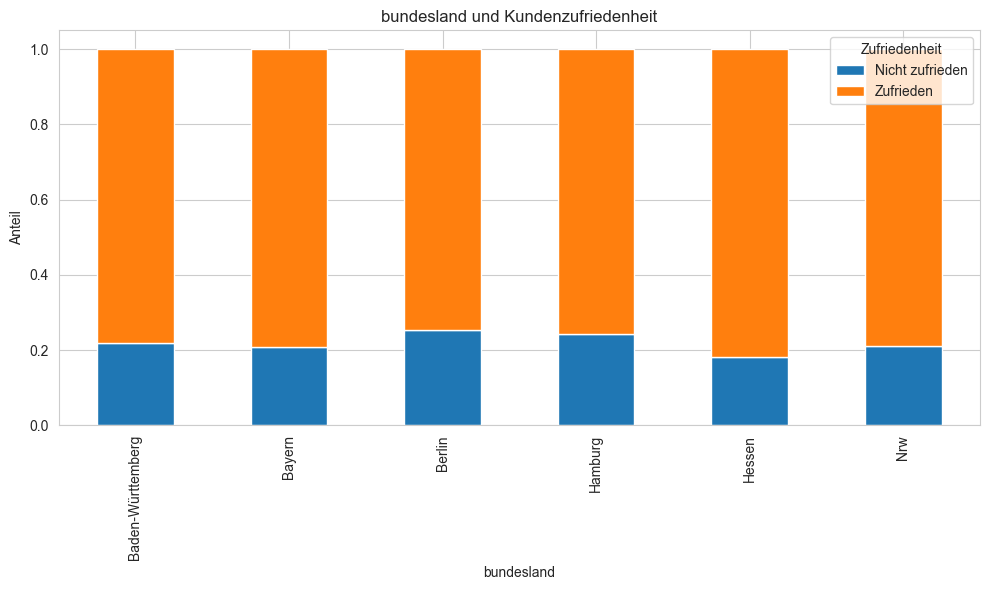

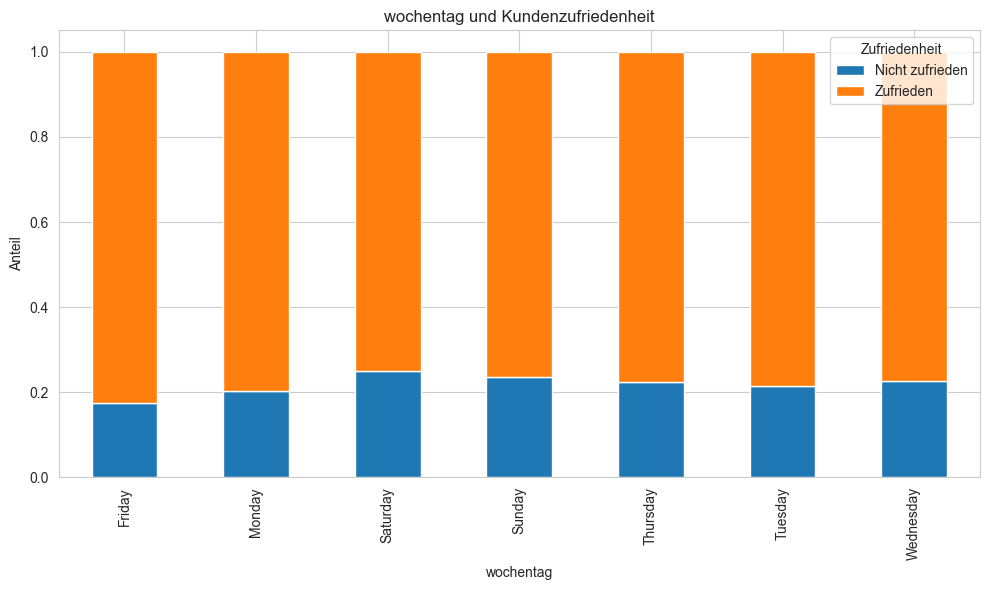

In [45]:
for feature in categorical_columns:

    table = pd.crosstab(
        df[feature],
        df["zufrieden"],
        normalize="index"
    )

    table.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )

    plt.title(
        f"{feature} und Kundenzufriedenheit"
    )

    plt.xlabel(feature)
    plt.ylabel("Anteil")

    plt.legend(
        title="Zufriedenheit",
        labels=[
            "Nicht zufrieden",
            "Zufrieden"
        ]
    )

    plt.tight_layout()
    plt.show()

Chi-Quadrat-Tests

In [46]:
from scipy.stats import chi2_contingency

for feature in categorical_columns:

    print("=" * 70)
    print(f"Variable: {feature}")

    table = pd.crosstab(
        df[feature],
        df["zufrieden"]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(table)
    )

    print(f"Chi²: {chi2:.3f}")
    print(f"p-Wert: {p_value:.5f}")

    if p_value < 0.05:
        print("H0 wird verworfen.")
        print(
            f"Zwischen {feature} und der Kundenzufriedenheit besteht ein signifikanter Zusammenhang."
        )
    else:
        print("H0 kann nicht verworfen werden.")
        print(
            f"Für {feature} konnte kein signifikanter Zusammenhang nachgewiesen werden."
        )

Variable: marke
Chi²: 0.266
p-Wert: 0.99192
H0 kann nicht verworfen werden.
Für marke konnte kein signifikanter Zusammenhang nachgewiesen werden.
Variable: modell
Chi²: 13.777
p-Wert: 0.79651
H0 kann nicht verworfen werden.
Für modell konnte kein signifikanter Zusammenhang nachgewiesen werden.
Variable: kraftstoff
Chi²: 0.557
p-Wert: 0.90624
H0 kann nicht verworfen werden.
Für kraftstoff konnte kein signifikanter Zusammenhang nachgewiesen werden.
Variable: getriebe
Chi²: 0.453
p-Wert: 0.50070
H0 kann nicht verworfen werden.
Für getriebe konnte kein signifikanter Zusammenhang nachgewiesen werden.
Variable: bundesland
Chi²: 3.712
p-Wert: 0.59152
H0 kann nicht verworfen werden.
Für bundesland konnte kein signifikanter Zusammenhang nachgewiesen werden.
Variable: wochentag
Chi²: 3.339
p-Wert: 0.76524
H0 kann nicht verworfen werden.
Für wochentag konnte kein signifikanter Zusammenhang nachgewiesen werden.


3. GEMEINSAME WIRKUNG ALLER VARIABLEN

Logistic Regression

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[
    numerical_columns +
    categorical_columns
]

y = df["zufrieden"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                )
            ]),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_columns
        )
    ]
)

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(
    X_train,
    y_train
)

print(
    "Train Accuracy:",
    model.score(X_train, y_train)
)

print(
    "Test Accuracy:",
    model.score(X_test, y_test)
)

Train Accuracy: 0.78125
Test Accuracy: 0.7791666666666667


c:\Users\User\anaconda3\envs\python_ki_kurs\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest – wichtigste Einflussfaktoren

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

rf.fit(
    X_train,
    y_train
)

print(
    "Train Accuracy:",
    rf.score(X_train, y_train)
)

print(
    "Test Accuracy:",
    rf.score(X_test, y_test)
)

Train Accuracy: 1.0
Test Accuracy: 0.775
